In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import MDAnalysis.analysis.distances
import MDAnalysis as md
import mdtraj as mdj
import MDAnalysis.analysis.contacts
import pandas as pd
import MDAnalysis.analysis.rms
import os
from MDAnalysis.analysis.dihedrals import Dihedral
from MDAnalysis.analysis.rms import RMSF
from MDAnalysis.analysis import rms, align
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

path = '/Volumes/Elements/PTM_project/SRSF2/pT14/'

In [3]:
# Calculate distances

# lysine residues to analyse
resnames = ['Met','Lys','Arg','Arg']
resids = [65,122,148,151] # in pdb file
atoms = ['N','NZ','CZ','CZ']

nsims=3

for i in range(1,nsims+1):
    
    print('Sim {}'.format(i))
    
    # load traj
    u = md.Universe(path+"sim{}/processed.pdb".format(i),path+"sim{}/fit.xtc".format(i))
    
    # atom selections
    sp2 = u.select_atoms('resname THP2 and name P')
    
    for rn,resi,at in zip(resnames,resids,atoms):
        
        l = u.select_atoms('resid {} and name {}'.format(resi,at))
        
        # calculate distances
        dist = []
        
        for frame in range(len(u.trajectory)):
            
            u.trajectory[frame]
            
            d = MDAnalysis.analysis.distances.dist(sp2,l)[2][0]
            
            dist.append(d)
            
        dist = np.array(dist)
        
        np.savetxt(path+"sim{}/{}{}{}_p14P_distance.txt".format(i,rn,resi-57,at),dist) # -57 to get right residue numbers
        
    
print('done')

Sim 1


/Users/olivierstreit/miniconda3/lib/python3.7/site-packages/MDAnalysis/topology/guessers.py:80: UserWarning: Failed to guess the mass for the following atom types: 
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))
/Users/olivierstreit/miniconda3/lib/python3.7/site-packages/MDAnalysis/topology/PDBParser.py:330: UserWarning: Element information is absent or missing for a few atoms. Elements attributes will not be populated.
  warnings.warn("Element information is absent or missing for a few "


Sim 2
Sim 3
done


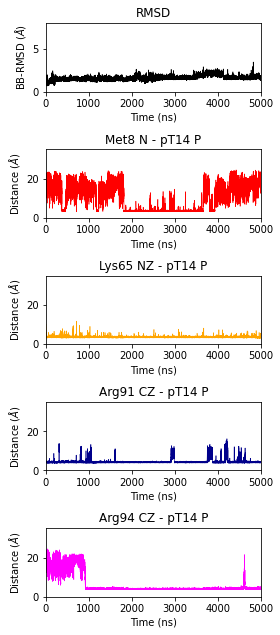

In [2]:

ymax = 35
ymax_rmsd = 8

resnames = ['Met','Lys','Arg','Arg']
resids = [65,122,148,151] # in pdb file
atoms = ['N','NZ','CZ','CZ']


sim=1

plt.figure(figsize = (4,12))

colors = ['red','orange','darkblue','magenta','lightblue','purple']

vals = []

dat = np.loadtxt(path+"sim{}/rmsd_BB.xvg".format(sim),skiprows=18)
    
rmsd = dat[:,1]*10 # convert to Angstrom
time = dat[:,0]/1000 # convert to nanoseconds

p=1

# three more panels
plt.subplot(7,1,p)
plt.title('RMSD')
plt.plot(time,rmsd,linewidth = 0.6,color = 'black')
plt.xlabel('Time (ns)')
plt.ylabel('BB-RMSD ($\\AA$)')
plt.ylim(0,ymax_rmsd)
plt.xlim(0,np.max(time))

for rn,resi,at,c in zip(resnames,resids,atoms,colors):
    p+=1
    dist = np.loadtxt(path+"sim{}/{}{}{}_p14P_distance.txt".format(sim,rn,resi-57,at))
    
    dat = np.loadtxt(path+"sim{}/rmsd_BB.xvg".format(sim),skiprows=18)
    
    rmsd = dat[:,1]*10 # convert to Angstrom
    time = dat[:,0]/1000 # convert to nanoseconds

    # three more panels
    plt.subplot(7,1,p)
    plt.plot(time,dist,color = c,linewidth = 0.6)
    plt.title('{}{} {} - pT14 P'.format(rn,resi-57,at))
    plt.ylim(0,ymax)
    plt.xlim(0,np.max(time))

    
    plt.xlabel('Time (ns)')
    plt.ylabel('Distance ($\\AA$)')


plt.tight_layout()
plt.savefig('THP2_P_distances_sim{}.png'.format(sim))



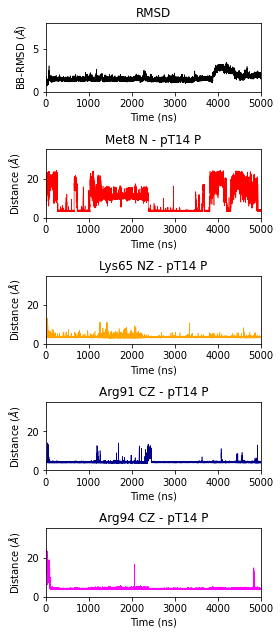

In [3]:

ymax = 35
ymax_rmsd = 8

resnames = ['Met','Lys','Arg','Arg']
resids = [65,122,148,151] # in pdb file
atoms = ['N','NZ','CZ','CZ']


sim=2

plt.figure(figsize = (4,12))

colors = ['red','orange','darkblue','magenta','lightblue','purple']

vals = []

dat = np.loadtxt(path+"sim{}/rmsd_BB.xvg".format(sim),skiprows=18)
    
rmsd = dat[:,1]*10 # convert to Angstrom
time = dat[:,0]/1000 # convert to nanoseconds

p=1

# three more panels
plt.subplot(7,1,p)
plt.title('RMSD')
plt.plot(time,rmsd,linewidth = 0.6,color = 'black')
plt.xlabel('Time (ns)')
plt.ylabel('BB-RMSD ($\\AA$)')
plt.ylim(0,ymax_rmsd)
plt.xlim(0,np.max(time))

for rn,resi,at,c in zip(resnames,resids,atoms,colors):
    p+=1
    dist = np.loadtxt(path+"sim{}/{}{}{}_p14P_distance.txt".format(sim,rn,resi-57,at))
    
    dat = np.loadtxt(path+"sim{}/rmsd_BB.xvg".format(sim),skiprows=18)
    
    rmsd = dat[:,1]*10 # convert to Angstrom
    time = dat[:,0]/1000 # convert to nanoseconds

    # three more panels
    plt.subplot(7,1,p)
    plt.plot(time,dist,color = c,linewidth = 0.6)
    plt.title('{}{} {} - pT14 P'.format(rn,resi-57,at))
    plt.ylim(0,ymax)
    plt.xlim(0,np.max(time))

    
    plt.xlabel('Time (ns)')
    plt.ylabel('Distance ($\\AA$)')


plt.tight_layout()
plt.savefig('THP2_P_distances_sim{}.png'.format(sim))




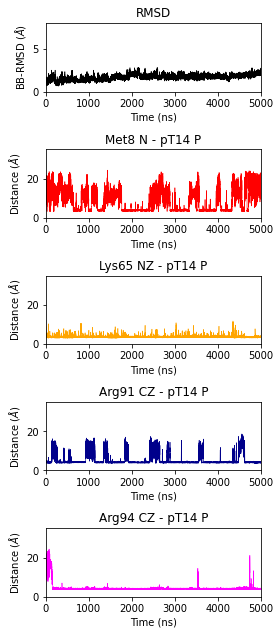

In [4]:

ymax = 35
ymax_rmsd = 8

resnames = ['Met','Lys','Arg','Arg']
resids = [65,122,148,151] # in pdb file
atoms = ['N','NZ','CZ','CZ']


sim=3

plt.figure(figsize = (4,12))

colors = ['red','orange','darkblue','magenta','lightblue','purple']

vals = []

dat = np.loadtxt(path+"sim{}/rmsd_BB.xvg".format(sim),skiprows=18)
    
rmsd = dat[:,1]*10 # convert to Angstrom
time = dat[:,0]/1000 # convert to nanoseconds

p=1

# three more panels
plt.subplot(7,1,p)
plt.title('RMSD')
plt.plot(time,rmsd,linewidth = 0.6,color = 'black')
plt.xlabel('Time (ns)')
plt.ylabel('BB-RMSD ($\\AA$)')
plt.ylim(0,ymax_rmsd)
plt.xlim(0,np.max(time))

for rn,resi,at,c in zip(resnames,resids,atoms,colors):
    p+=1
    dist = np.loadtxt(path+"sim{}/{}{}{}_p14P_distance.txt".format(sim,rn,resi-57,at))
    
    dat = np.loadtxt(path+"sim{}/rmsd_BB.xvg".format(sim),skiprows=18)
    
    rmsd = dat[:,1]*10 # convert to Angstrom
    time = dat[:,0]/1000 # convert to nanoseconds

    # three more panels
    plt.subplot(7,1,p)
    plt.plot(time,dist,color = c,linewidth = 0.6)
    plt.title('{}{} {} - pT14 P'.format(rn,resi-57,at))
    plt.ylim(0,ymax)
    plt.xlim(0,np.max(time))

    
    plt.xlabel('Time (ns)')
    plt.ylabel('Distance ($\\AA$)')


plt.tight_layout()
plt.savefig('THP2_P_distances_sim{}.png'.format(sim))




0.9939550302248489
0.002012877579437936
0.8956471884307246
0.043232942812917736
0.9928733689664885
0.00012974982402528718


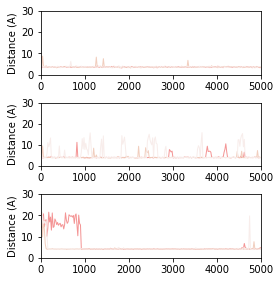

In [13]:
# individual simulation plots of the buried PTMs

resnames = ['Lys','Arg','Arg']
resids = [122,148,151] # in pdb file
atoms = ['NZ','CZ','CZ']
fullnames = []
for resn,resi in zip(resnames,resids):
    fullnames.append(resn+str(resi-57))

colors = ['#F49595','#F1CEBE','#F8EDEB']

nsims=3
Nmov = 50

plt.figure(figsize= (4,5))

df = pd.DataFrame()

averages = []
errors = []
IDX=1
for rn,resi,at in zip(resnames,resids,atoms):
    
    plt.subplot(4,1,IDX)
    
    vals = []
    
    for s in range(1,nsims+1):
        dist = np.loadtxt(path+"sim{}/{}{}{}_p14P_distance.txt".format(s,rn,resi-57,at))
        DAT_FOR_AVG = dist[50000:] # discard first 1us for average
        DAT_FOR_AVG = (DAT_FOR_AVG<5.0)*1
        vals.append(np.mean(DAT_FOR_AVG))
        dist = dist[::1000]
        dat = np.loadtxt(path+"sim{}/rmsd_BB.xvg".format(s),skiprows=18)[::1000]
        time = dat[:,0]/1000 # convert to nanoseconds
        
        plt.plot(time,dist,color = colors[s-1],linewidth = 1.0)
    

    mu = np.mean(vals)
    err = np.std(vals)/np.sqrt(3)
    averages.append(mu)
    errors.append(err)
    
    print(mu)
    print(err)
    plt.ylim(0,30)
    plt.xlim(0,5000)

    if IDX==4:
        plt.xlabel('Time (ns)')
        plt.ylabel('Distance (A)')
    else:
        plt.ylabel('Distance (A)')

    IDX+=1

        
df['Residue'] = fullnames
df['Probability'] = np.round(averages,2)
df['Error'] = np.round(errors,2)
df.to_csv('Phosphate_contact_prob.csv')


plt.tight_layout()
plt.savefig('final_distances.pdf')

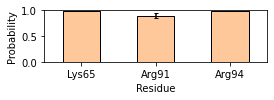

In [14]:
# plot
df = pd.read_csv('Phosphate_contact_prob.csv')
df.plot(x='Residue',y='Probability',yerr= np.array(df['Error']),
       kind='bar',figsize = (4,1.5),legend=False,color = '#FEC89A',edgecolor = 'black',
       capsize = 2)

plt.xticks(rotation=0)
plt.ylim(0,1)

plt.ylabel('Probability')

plt.tight_layout()
plt.savefig('phosphate_contact_prob_barplot.pdf')

In [15]:
df

,Unnamed: 0,Residue,Probability,Error
0,0,Lys65,0.99,0.00
1,1,Arg91,0.90,0.04
2,2,Arg94,0.99,0.00


In [18]:
resn+str(resi)

'Arg151'